# Segmentation des clients olist : analyse exploratoire

### Table des matières

* [**1. Introduction**](#chapter1)
* [**2.Analyse générale**](#chapter2)
    * [2.1. Chargement](#section_2_1)
    * [2.2. Entêtes](#section_2_2)
    * [2.3. Valeurs manquantes](#section_2_3)
    * [2.4. Dimensions](#section_2_4)
    * [2.5. Types](#section_2_5)
    * [2.6. Doublons](#section_2_6)
* [**3. Analyse des datasets**](#chapter3)
    * [3.1. Orders](#section_3_1)
    * [3.2. Payments](#section_3_2)
    * [3.3. Customers](#section_3_3)
    * [3.4. Order items](#section_3_4)
    * [3.5. Order reviews](#section_3_5)
    * [3.6. Products](#section_3_6)
* [**4. Merging**](#chapter4)
    * [4.1. Order items](#section_4_1)
    * [4.2. Orders](#section_4_2)
    * [4.3. Customers](#section_4_3)
* [**5. RFM - Feature engineering**](#chapter5)
* [**6. Conclusion**](#chapter6)


## 1 - Introduction <a class="anchor" id="chapter1"></a>



Ce document contient une analyse exploratoire des datesets olist.  
Les données utiles sont extraites afin d'être utilisées par des algorithmes de clustering.  
L'objectif est de segmenter les clients afin de mieux les cibler lors de campagnes de communication.  



## 2 - Analyse générale <a class="anchor" id="chapter2"></a>


### 2.1 - Chargement <a class="anchor" id="section_2_1"></a>

In [541]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn')

In [542]:
data_path = "./datas/"

In [543]:
df_orders = pd.read_csv(data_path + "olist_orders_dataset.csv", low_memory=False)
df_customers = pd.read_csv(data_path + "olist_customers_dataset.csv", low_memory=False)
df_geolocation = pd.read_csv(data_path + "olist_geolocation_dataset.csv", low_memory=False)
df_order_items = pd.read_csv(data_path + "olist_order_items_dataset.csv", low_memory=False)
df_order_payments = pd.read_csv(data_path + "olist_order_payments_dataset.csv", low_memory=False)
df_order_reviews = pd.read_csv(data_path + "olist_order_reviews_dataset.csv", low_memory=False)
df_products = pd.read_csv(data_path + "olist_products_dataset.csv", low_memory=False)
df_sellers = pd.read_csv(data_path + "olist_sellers_dataset.csv", low_memory=False)
df_product_category_name_translation = pd.read_csv(data_path + "product_category_name_translation.csv", low_memory=False)



In [544]:
#datasets_names=['orders', 'customers', 'geolocation', 'order_items', 'order_payments', 'order_reviews', 'products', 'sellers', 'product_category_name_translation']
datasets={}
datasets['orders'] = df_orders
datasets['customers'] = df_customers
datasets['geolocation'] = df_geolocation
datasets['order_items'] = df_order_items
datasets['order_payments'] = df_order_payments
datasets['order_reviews'] = df_order_reviews
datasets['products'] = df_products
datasets['sellers'] = df_sellers
datasets['product_category_name_translation'] = df_product_category_name_translation


### 2.2 - Aperçu des entêtes <a class="anchor" id="section_2_2"></a>

In [545]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [546]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [547]:
df_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [548]:
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [549]:
df_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [550]:
df_order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [551]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [552]:
df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [553]:
df_product_category_name_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### 2.3 - Valeurs manquantes <a class="anchor" id="section_2_3"></a>

In [554]:

# affichage du pourcentage des valeurs manquantes par colonne pour une dataframe donnée ainsi que le seuil choisi
def graph_valeurs_manquantes(df_valeurs_manquantes):
    """Plot a barplot of the missing value dataframe in parameter

        Parameters:
        df_valeurs_manquantes (dataframe): The dataframe in valeurs_manquantes format

        Returns:
        plt:the barplot

    """    
    plt.figure(figsize=(30,15))
    sns.barplot(data=df_valeurs_manquantes,x=df_valeurs_manquantes['colonne'],y=df_valeurs_manquantes['% de valeurs manquantes'])
    plt.xticks(fontsize=14, rotation = 90)
    return plt.show()

def valeurs_manquantes_ds(datasets,sort=False):
    """create a dataframe with missing values ratios for each column of each dataset from parameters

        Parameters:
        datasets (dict): Datasets dict
        sort (boolean): sort values if true

        Returns:
        dataframe: missing values dataframe

    """    
    df_valeurs_manquantes = pd.DataFrame()
    for dataset_name in datasets:
        dataset = datasets[dataset_name]
        valeurs_manquantes = ((dataset.isna().sum()/dataset.shape[0])*100).sort_values(ascending=False)  
        df = valeurs_manquantes.rename_axis('colonne').reset_index(name='% de valeurs manquantes')
        df['dataset']=dataset_name
        df_valeurs_manquantes = pd.concat([df_valeurs_manquantes, df], ignore_index=True)
    df_valeurs_manquantes.insert(0, 'dataset', df_valeurs_manquantes.pop('dataset')) 
    if (sort):
        df_valeurs_manquantes = df_valeurs_manquantes.sort_values(by=['% de valeurs manquantes'],ascending=False)        
    return df_valeurs_manquantes

def valeurs_manquantes_df(df):
    """Plot a barplot of missing values of the dataframe in parameter

        Parameters:
        df (dataframe): the dataframe from which calculate missing values

        Returns:
        plt:the barplot with missing values

    """    
    valeurs_manquantes = ((df.isna().sum()/df.shape[0])*100).sort_values(ascending=False)  
    df_valeurs_manquantes = pd.DataFrame(valeurs_manquantes,columns=['% de valeurs manquantes'])
    plt.figure(figsize=(30,15))
    sns.barplot(data=df_valeurs_manquantes,x=df_valeurs_manquantes.index,y=df_valeurs_manquantes.columns[0])
    plt.xticks(rotation = 90)
    return plt.show()


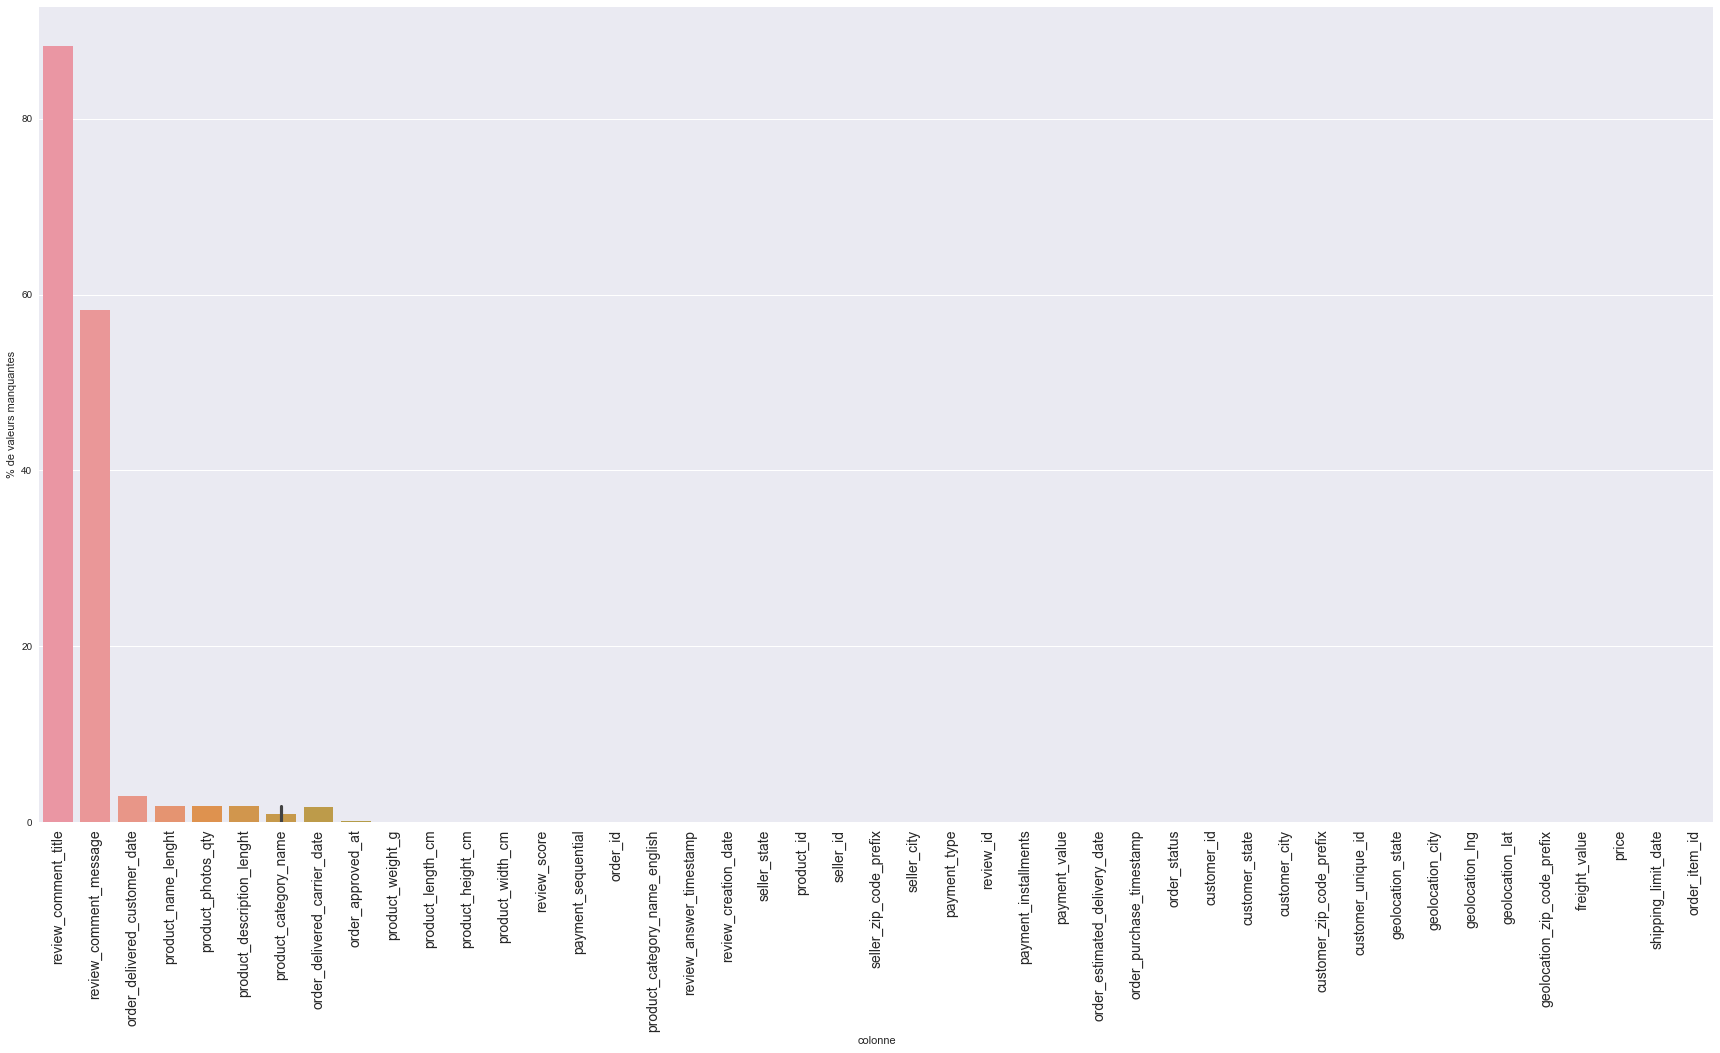

In [555]:
graph_valeurs_manquantes(valeurs_manquantes_ds(datasets,True))

In [556]:
valeurs_manquantes_ds(datasets,True).head(15)

,dataset,colonne,% de valeurs manquantes
30,order_reviews,review_comment_title,88.285000
31,order_reviews,review_comment_message,58.247000
0,orders,order_delivered_customer_date,2.981668
39,products,product_name_lenght,1.851234
37,products,product_photos_qty,1.851234
38,products,product_description_lenght,1.851234
40,products,product_category_name,1.851234
1,orders,order_delivered_carrier_date,1.793023
2,orders,order_approved_at,0.160899
44,products,product_weight_g,0.006070


Très peu de colonnes ont des valeurs manquantes.  
Deux colonnes ont beaucoup de valeurs manquantes, ce sont les commentaires client, ce qui est normal, tous les clients ne mettent pas de commentaires.  
Les autres colonnes ont très peu de valeurs manquantes.  
Ces valeurs manquantes seront traitées selon si ces colonnes sont utilisées ou non dans l'étude.  


### 2.4 - Dimensions<a class="anchor" id="section_2_4"></a>

In [557]:

df_shapes = pd.DataFrame(columns=['dataset','lignes','colonnes']) # initialize dataframe

for dataset in datasets:
    # add dataset shape for each dataset in datasets
    df_shapes = df_shapes.append({
        'dataset' : dataset ,
        'lignes' : datasets[dataset].shape[0],
        'colonnes' : datasets[dataset].shape[1]} , ignore_index=True)
df_shapes

,dataset,lignes,colonnes
0,orders,99441,8
1,customers,99441,5
2,geolocation,1000163,5
3,order_items,112650,7
4,order_payments,103886,5
5,order_reviews,100000,7
6,products,32951,9
7,sellers,3095,4
8,product_category_name_translation,71,2


Les commandes et les clients ont le même nombre de ligne.  
Cela est dû au fait qu'un numéro de client au client est affecté à chaque nouvelle commande, en plus du numéro unique du client.  

Les datasets associés aux commandes ont un nombre de lignes similaires aux commandes.  
Le dataset geolocation a un grand nombre de lignes.

### 2.5 - Les types de données <a class="anchor" id="section_2_5"></a>

In [558]:
def value_counts_transpose(value_counts):
    """transpose a value_counts values

        Parameters:
        value_counts : the value_counts values

        Returns:
        df: df containing value_counts transposed

    """    
    df = value_counts.rename_axis('index').reset_index(name='counts')
    df = df.set_index('index').T
    df = df.reset_index()
    df = df.drop(columns=['index'])
    return df
    

In [559]:


df_types = pd.DataFrame() 

for dataset_name in datasets:
    # concat df_types values with types from datasets
    dataset = datasets[dataset_name]
    value_counts = dataset.dtypes.value_counts()
    df_types_current = value_counts_transpose(value_counts)
    df_types_current.insert(0, 'dataset', dataset_name) 
    df_types = pd.concat([df_types, df_types_current], ignore_index=True)
    

In [560]:
df_types

,dataset,object,int64,float64
0,orders,8,NaN,NaN
1,customers,4,1.0,NaN
2,geolocation,2,1.0,2.0
3,order_items,4,1.0,2.0
4,order_payments,2,2.0,1.0
5,order_reviews,6,1.0,NaN
6,products,2,NaN,7.0
7,sellers,3,1.0,NaN
8,product_category_name_translation,2,NaN,NaN


Beaucoup de colonnes sont des variables non numériques.

### 2.6 - Doublons <a class="anchor" id="section_2_6"></a>

In [561]:

def dataset_duplicated(df,key): 
    """calculate dataframe duplicated values

        Parameters:
        df (dataframe): the datframe from which calculate duplicates
        key (array): the dataframe key 

        Returns:
        df: dataframe containing duplicated values

    """    
    if key == '':
        value_counts = dataset.duplicated().value_counts()
    else:
        value_counts = dataset.duplicated(subset=dataset_key).value_counts()
    df = value_counts_transpose(value_counts)
    return df

Les clés des tables:  
Les tables orders, products et sellers ont une colonne représentant l'identifiant de la ligne.  
Les lignes des tables order_items, order_payments et order_reviews sont identifiées par order_id + un autre identifiant.  

La table customers possède une colonne customer_unique_id et customer_id.  
Plusieurs customer_id (associé à une seule commande) peuvent être associés au customer_unique_id.  
Il ne peut y avoir par contre qu'un seul couple customer_unique_id / customer_id.  


In [562]:

# datasets_keys initialization

datasets_keys={}

datasets_keys['products'] = ['product_id']
datasets_keys['sellers'] =  ['seller_id']
datasets_keys['orders'] = ['order_id']
datasets_keys['order_items'] = ['order_id','order_item_id']
datasets_keys['order_reviews'] = ['order_id','review_id']
datasets_keys['order_payments'] = ['order_id','payment_sequential']
datasets_keys['customers'] = ['customer_id','customer_unique_id']
datasets_keys['geolocation'] = ['geolocation_lat','geolocation_lng']
datasets_keys['product_category_name_translation'] = 'product_category_name'

In [563]:


df_doublons = pd.DataFrame()

for dataset_name in datasets:
    # concatene df_doublons with duplicated values from each dataset
    
    dataset = datasets[dataset_name]
    dataset_key = datasets_keys[dataset_name]
    dataset_lignes=dataset.shape[0]
    
    df_dupl_without_key = dataset_duplicated(dataset,'')
    df_dupl_with_key = dataset_duplicated(dataset,dataset_key)

    df_doublons_current['dataset'] = dataset_name
    df_doublons_current['doublons sur la ligne'] = dataset_lignes - df_dupl_without_key[False]
    df_doublons_current['doublons sur la clé'] = dataset_lignes - df_dupl_with_key[False]
    
    df_doublons = pd.concat([df_doublons, df_doublons_current], ignore_index=True)
    
df_doublons.insert(0, 'dataset', df_doublons.pop('dataset')) 


In [564]:
df_doublons

,dataset,doublons sur la ligne,doublons sur la clé
0,orders,0,0
1,customers,0,0
2,geolocation,261831,281700
3,order_items,0,0
4,order_payments,0,0
5,order_reviews,0,0
6,products,0,0
7,sellers,0,0
8,product_category_name_translation,0,0


Il y a de nombreux doublons dans la table geolocation.


## 3 - Analyse des datasets <a class="anchor" id="chapter3"></a>


### 3.1 - Orders <a class="anchor" id="section_3_1"></a>

#### Les statuts des commandes:

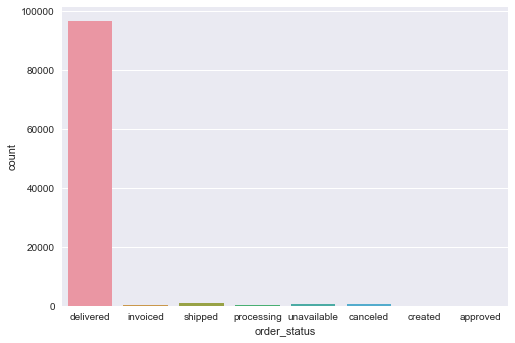

In [565]:
ax = sns.countplot(x="order_status", data=df_orders)


In [566]:
delivered_percent = round((df_orders[df_orders['order_status']=='delivered'].shape[0]/df_orders.shape[0])*100,2)
print(f'{delivered_percent} % des commandes ont un statut delivered')

97.02 % des commandes ont un statut delivered


#### Dates des commandes:

In [567]:
df_delivered = df_orders.query('order_status == "delivered"')
df_delivered.isna().sum()


order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

order_purchase_timestamp correspond à la date où l'achat a été effectué par le client.  
Cette date est présente pour toutes les commandes ayant un statut delivered.  
Pour classifier les clients, les commandes délivrées sont gardées et la date order_purchase_timestamp servira de date de référence.  


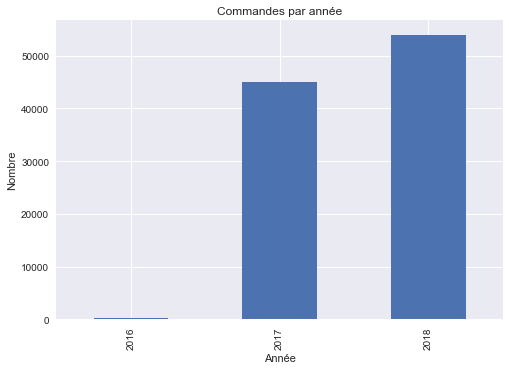

In [568]:
df_orders.groupby(pd.to_datetime(df_orders['order_purchase_timestamp']).dt.year).agg({"order_id": "nunique"}).plot(
    kind="bar",
    title="Commandes par année",
    xlabel="Année",
    ylabel="Nombre",
    legend=False)
plt.show()


Les commandes sont étalées sur 3 ans, principalement sur deux : 2017 et 2018.  

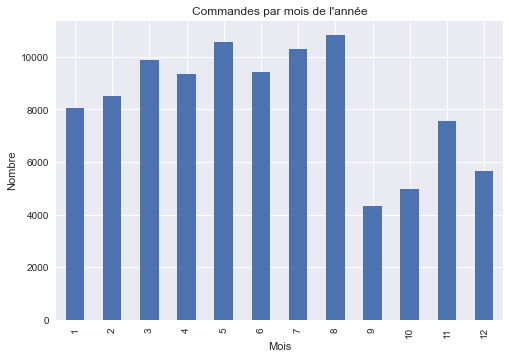

In [569]:
df_orders.groupby(pd.to_datetime(df_orders['order_purchase_timestamp']).dt.month).agg({"order_id": "nunique"}).plot(
    kind="bar",
    title="Commandes par mois de l'année",
    xlabel="Mois",
    ylabel="Nombre",
    legend=False)
plt.show()


Moins de commandes ont été passées sur les fins d'années que sur les débuts.  
Sur deux années, ces chiffres ne sont pas forcément représentatifs.

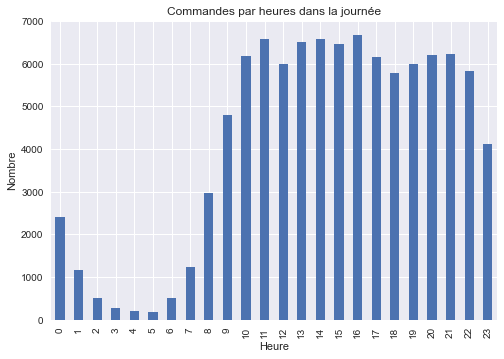

In [570]:
df_orders.groupby(pd.to_datetime(df_orders['order_purchase_timestamp']).dt.hour).agg({"order_id": "nunique"}).plot(
    kind="bar",
    title="Commandes par heures dans la journée",
    xlabel="Heure",
    ylabel="Nombre",
    legend=False)
plt.show()

Quelques commandes sont effectuées la nuit.  
Il y a beaucoup de commandes effectuées de 10 heures à 22 heures.  
Moins tôt le matin ou tard le soir.  

L'heure à laquelle l'achat est effectué peut être dépendant de profils de clients.  
Cette information sera ajoutée au dataset.

#### délais de livraison

Les clients attribuent une note suite à leur achat.  
Cette note peut être due au délai de livraison.  

In [571]:
df_orders['delivery_delay'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])-pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['delivery_delay_days'] = df_orders['delivery_delay'].dt.days

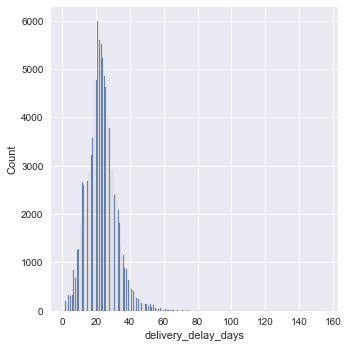

In [572]:
sns.displot(df_orders['delivery_delay_days'])
plt.show()

Les délais sont d'environ 20 jours.   
Certains délais sont bien supérieurs.  

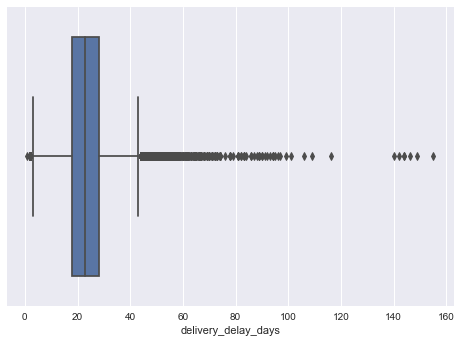

In [573]:
sns.boxplot(df_orders['delivery_delay_days'])
plt.show()

Les délais au delà de 40 jours (environ) sont atypiques.  
Cependant, des délais jusque 150 jours ne sont pas absurdes, toutes ces dates seront gardées.  

### 3.2 - Payments <a class="anchor" id="section_3_2"></a>

In [574]:
df_order_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


#### Les types de paiement

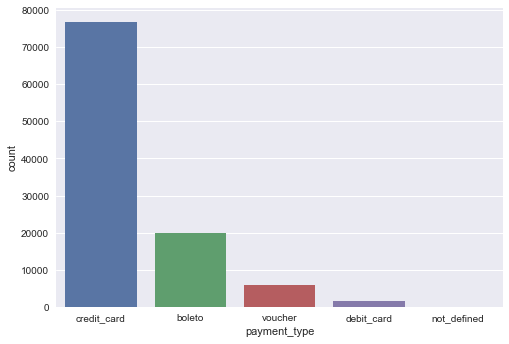

In [575]:
ax = sns.countplot(x="payment_type", data=df_order_payments)


Le plupart des paiements sont effectués par carte bancaire.  
Il y a 5 types de paiement.

#### Les montants

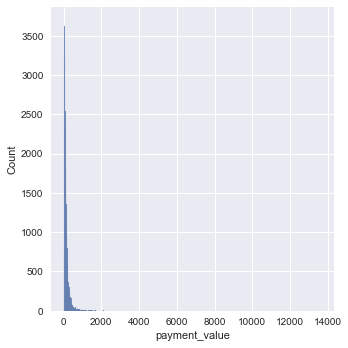

In [576]:
sns.displot(df_order_payments['payment_value'])
plt.show()

La plupart des paiement ont une valeur inférieure à 2000 euros.  
14000 euros semble être une valeur erronée.  

In [577]:
df_order_payments[df_order_payments['payment_value']>10000]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08


In [578]:
df_order_items[df_order_items['order_id']=='03caa2c082116e1d31e67e9ae3700499']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
1647,03caa2c082116e1d31e67e9ae3700499,1,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1648,03caa2c082116e1d31e67e9ae3700499,2,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1649,03caa2c082116e1d31e67e9ae3700499,3,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1650,03caa2c082116e1d31e67e9ae3700499,4,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1651,03caa2c082116e1d31e67e9ae3700499,5,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1652,03caa2c082116e1d31e67e9ae3700499,6,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1653,03caa2c082116e1d31e67e9ae3700499,7,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1654,03caa2c082116e1d31e67e9ae3700499,8,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01


In [579]:
df_products[df_products['product_id']=='5769ef0a239114ac3a854af00df129e4']

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
25620,5769ef0a239114ac3a854af00df129e4,telefonia_fixa,39.0,2493.0,3.0,750.0,16.0,16.0,16.0


Un produit de la catégorie téléphone fixe a été commandé 8 fois dans la même commande et facturé 1680 euros àchaque fois.  
Cela semble une erreur.  
Les commandes ayant des valeurs de paiement aberrantes seront supprimées.  

#### nombre de paiements par commande

In [580]:
df_order_payments['order_id'].value_counts()

fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
                                    ..
2bb1693e6826b1ef5f46a4e33f0dbef8     1
49df58eca26497b2af5a5685006f9615     1
1dfe970583e8a1a09241aa32a815a5b4     1
931b5b510d21c486fe86269b2e36fedb     1
899499ccb61cd1525c8b04047ac70e0d     1
Name: order_id, Length: 99440, dtype: int64

In [581]:
df_order_payments[df_order_payments['order_id']=='fa65dad1b0e818e3ccc5cb0e39231352']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
4885,fa65dad1b0e818e3ccc5cb0e39231352,27,voucher,1,66.02
9985,fa65dad1b0e818e3ccc5cb0e39231352,4,voucher,1,29.16
14321,fa65dad1b0e818e3ccc5cb0e39231352,1,voucher,1,3.71
17274,fa65dad1b0e818e3ccc5cb0e39231352,9,voucher,1,1.08
19565,fa65dad1b0e818e3ccc5cb0e39231352,10,voucher,1,12.86
23074,fa65dad1b0e818e3ccc5cb0e39231352,2,voucher,1,8.51
24879,fa65dad1b0e818e3ccc5cb0e39231352,25,voucher,1,3.68
28330,fa65dad1b0e818e3ccc5cb0e39231352,5,voucher,1,0.66
29648,fa65dad1b0e818e3ccc5cb0e39231352,6,voucher,1,5.02
32519,fa65dad1b0e818e3ccc5cb0e39231352,11,voucher,1,4.03


Ce client a payé en 29 fois.

### 3.3 - Customers <a class="anchor" id="section_3_3"></a>

In [582]:
df_customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


#### nombre de commandes par client:

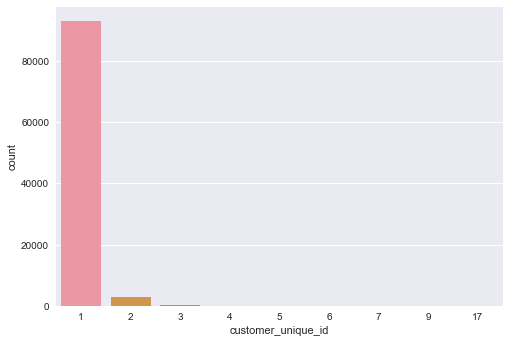

In [583]:
sns.countplot(df_customers['customer_unique_id'].value_counts())
plt.show()

La plupart des clients n'ont fait qu'une seule commande.

#### répartition des clients par villes et états

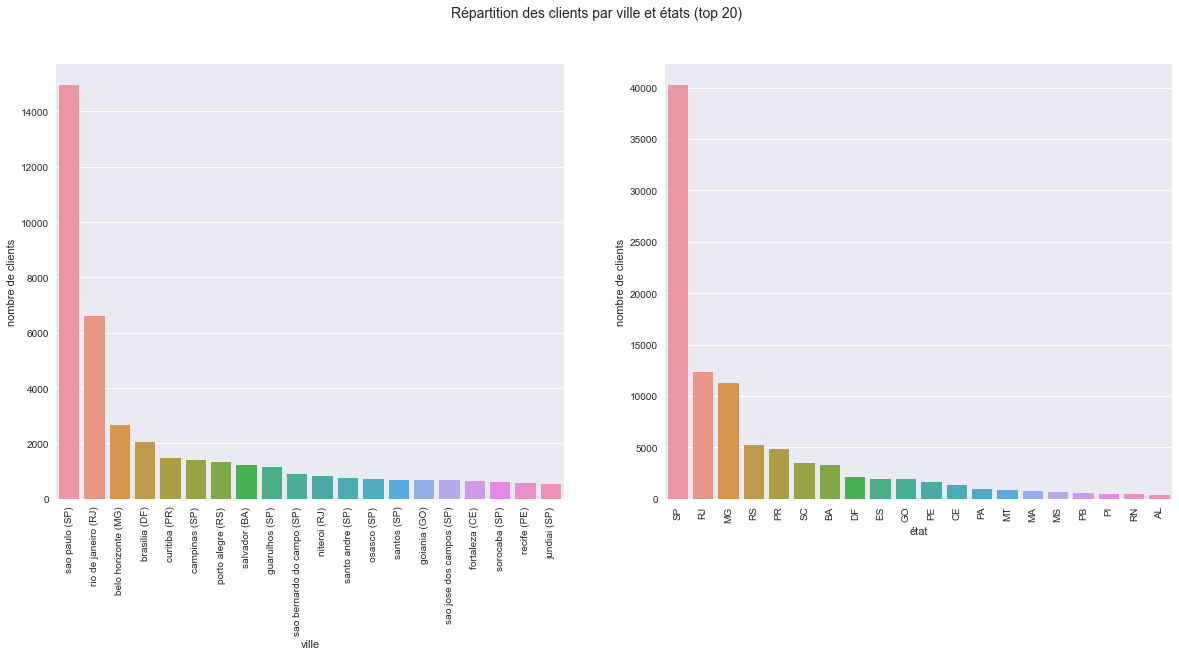

In [584]:

# create a dataframe with unique customers
df_unique_customer = df_customers.drop_duplicates(subset=['customer_unique_id'])
df_unique_customer['customer_city_state'] = df_unique_customer['customer_city'] + ' (' + df_unique_customer['customer_state'] + ')'

# group customers per city
df_customer_group_city = df_unique_customer.groupby('customer_city_state').agg({
    'customer_unique_id': lambda x: len(x)
}).reset_index()

# group customers per state
df_customer_group_state = df_unique_customer.groupby('customer_state').agg({
    'customer_unique_id': lambda x: len(x)
}).reset_index()


# plot barplots from these unique customers groupped dataframes

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Répartition des clients par ville et états (top 20)", fontsize=14)

g1 = sns.barplot(ax=axes[0],data=df_customer_group_city.sort_values(by=['customer_unique_id'], ascending=False).head(20),x='customer_city_state',y='customer_unique_id')
g1.set_xticklabels(g1.get_xticklabels(), rotation=90) 
g1.set_xlabel("ville")
g1.set_ylabel("nombre de clients")

g2 = sns.barplot(ax=axes[1],data=df_customer_group_state.sort_values(by=['customer_unique_id'], ascending=False).head(20),x='customer_state',y='customer_unique_id')
g2.set_xticklabels(g2.get_xticklabels(), rotation=90) 
g2.set_xlabel("état")
g2.set_ylabel("nombre de clients")

plt.show()

Ce sont les clients de Sao Paulo qui sont les plus nombreux.

### 3.4 - Order items <a class="anchor" id="section_3_4"></a>

In [585]:
df_order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


#### nombre de produits par commandes

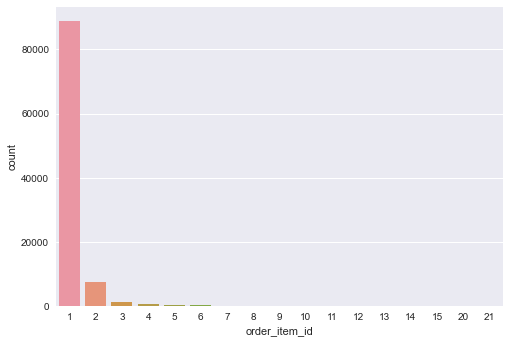

In [586]:
# number of products per order
df_items_group_order = df_order_items.groupby('order_id').agg({
    'order_item_id': lambda x: len(x)
})

ax = sns.countplot(x="order_item_id", data=df_items_group_order)


La plupart des commandes n'ont qu'un produit.   
Certaines vont jusqu'à 21 produits.

#### produits commandés par vendeurs

In [587]:

# items group by sellers
df_items_group_seller = df_order_items.groupby('seller_id').agg({
    'product_id': lambda x: len(x)
}).reset_index()


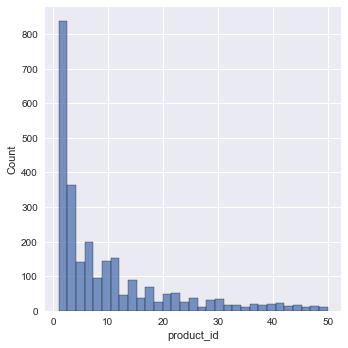

In [588]:
sns.displot(data=df_items_group_seller[df_items_group_seller['product_id']<=50],x='product_id')
plt.show()

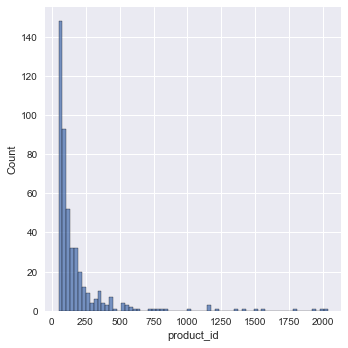

In [589]:
sns.displot(data=df_items_group_seller[df_items_group_seller['product_id']>50],x='product_id')
plt.show()

La plupart des vendeurs ne vendent qu'un type de produit.  
Certains vendeurs proposent 2000 produits.

### 3.5 - Order reviews <a class="anchor" id="section_3_5"></a>

#### Répartition des scores

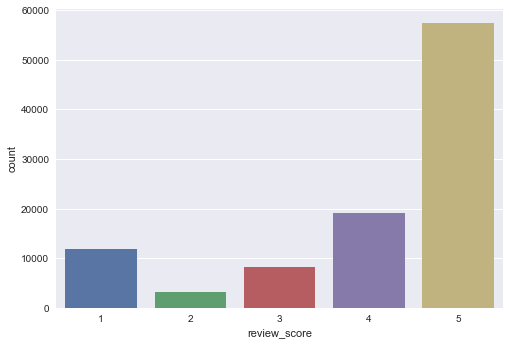

In [590]:
ax = sns.countplot(x="review_score", data=df_order_reviews)


Les scores vont de 1 à 5.  


#### reviews par commandes

In [591]:

# reviews group by orders
df_order_reviews_group = df_order_reviews.groupby('order_id').agg({
    'review_score': lambda x: np.mean(x),
    'review_id': lambda x: len(x)
})

df_order_reviews_group['review_id'].value_counts()

1    98886
2      551
3        4
Name: review_id, dtype: int64

Certaines commandes ont deux ou 3 reviews.  

Un exemple:  

In [592]:
df_order_reviews_group[df_order_reviews_group['review_id']>2]

,review_score,review_id
order_id,,
03c939fd7fd3b38f8485a0f95798f1f6,3.333333,3
8e17072ec97ce29f0e1f111e598b0c85,1.000000,3
c88b1d1b157a9999ce368f218a407141,4.333333,3
df56136b8031ecd28e200bb18e6ddb2e,5.000000,3


In [593]:
df_order_reviews[df_order_reviews['order_id']=='03c939fd7fd3b38f8485a0f95798f1f6']

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
8329,b04ed893318da5b863e878cd3d0511df,03c939fd7fd3b38f8485a0f95798f1f6,3,NaN,Um ponto negativo que achei foi a cobrança de ...,2018-03-20 00:00:00,2018-03-21 02:28:23
51931,f4bb9d6dd4fb6dcc2298f0e7b17b8e1e,03c939fd7fd3b38f8485a0f95798f1f6,4,NaN,NaN,2018-03-29 00:00:00,2018-03-30 00:29:09
70005,405eb2ea45e1dbe2662541ae5b47e2aa,03c939fd7fd3b38f8485a0f95798f1f6,3,NaN,Seria ótimo se tivesem entregue os 3 (três) pe...,2018-03-06 00:00:00,2018-03-06 19:50:32


### 3.6 - Products <a class="anchor" id="section_3_6"></a>

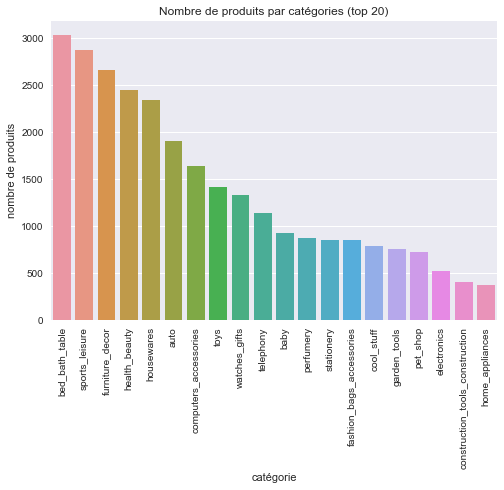

In [594]:

# merge category translation with products
df_products_extend = df_products.merge(
    df_product_category_name_translation, how='left', on=['product_category_name'])

# group products by categories
df_product_group_category = df_products_extend.groupby('product_category_name_english').agg({
    'product_id': lambda x: len(x)
}).reset_index()

# plotting barplot
g1 = sns.barplot(data=df_product_group_category.sort_values(by=['product_id'], ascending=False).head(20),x='product_category_name_english',y='product_id')
g1.set_xticklabels(g1.get_xticklabels(), rotation=90) 
g1.set_xlabel("catégorie")
g1.set_ylabel("nombre de produits")
g1.set_title("Nombre de produits par catégories (top 20)")

plt.show()

In [595]:
df_products['product_category_name'].value_counts()

cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
casa_conforto_2                     5
fashion_roupa_infanto_juvenil       5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: product_category_name, Length: 73, dtype: int64

In [596]:
category_count = len(df_products['product_category_name'].value_counts())
print(f'Les produits vendus sont répartis dans {category_count} catégories.')

Les produits vendus sont répartis dans 73 catégories.


## 4 - Merging <a class="anchor" id="chapter4"></a>


### 4.1 - Order items <a class="anchor" id="section_4_1"></a>

#### Merge des produits et des vendeurs avec les lignes de commande

In [597]:

# merge orders_items, products, sellers 
df_orders_items_extend = df_order_items.merge(
    df_products_extend, how='outer', on=['product_id']).merge(
    df_sellers, how='outer', on=['seller_id'])


##### Les catégories de produit les plus vendues:

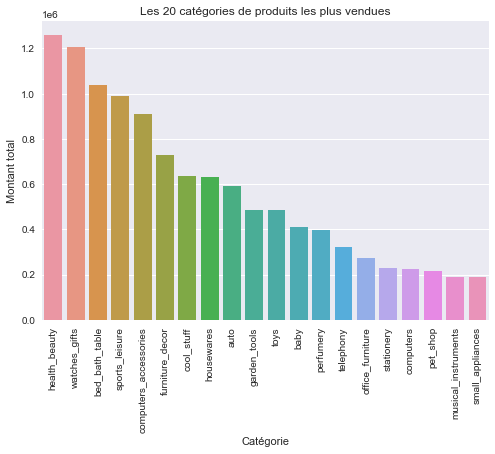

In [598]:

# group items by categories
df_items_group_category = df_orders_items_extend.groupby('product_category_name_english').agg({
    'price': lambda x: sum(x)
}).reset_index()

# plotting barplot
g1 = sns.barplot(data=df_items_group_category.sort_values(by=['price'], ascending=False).head(20),x='product_category_name_english',y='price')
g1.set_xticklabels(g1.get_xticklabels(), rotation=90) 
g1.set_xlabel("Catégorie")
g1.set_ylabel("Montant total")
g1.set_title("Les 20 catégories de produits les plus vendues")

plt.show()


##### Les ventes par villes et états des vendeurs

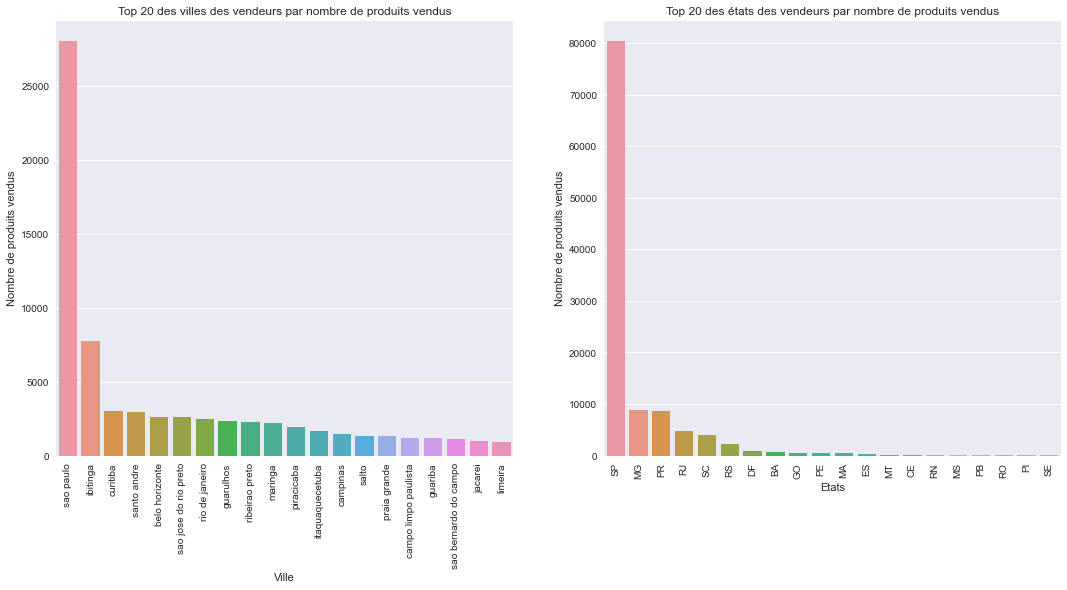

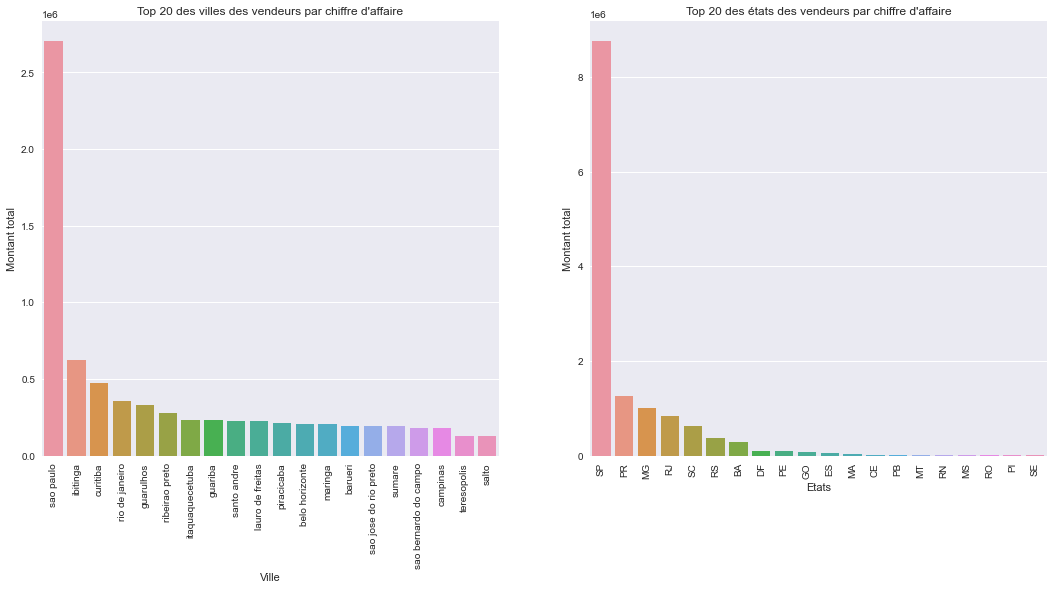

In [599]:

# group items by cities
df_items_group_city = df_orders_items_extend.groupby('seller_city').agg({
    'product_id': lambda x: len(x),
    'price': lambda x: sum(x)
}).reset_index()

# group items by states
df_items_group_state = df_orders_items_extend.groupby('seller_state').agg({
    'product_id': lambda x: len(x),
    'price': lambda x: sum(x)
}).reset_index()

# plot categories by top selling products

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

g1 = sns.barplot(ax=axes[0], data=df_items_group_city.sort_values(by=['product_id'], ascending=False).head(20),x='seller_city',y='product_id')
g1.set_xticklabels(g1.get_xticklabels(), rotation=90) 
g1.set_xlabel("Ville")
g1.set_ylabel("Nombre de produits vendus")
g1.set_title("Top 20 des villes des vendeurs par nombre de produits vendus")

g2 = sns.barplot(ax=axes[1], data=df_items_group_state.sort_values(by=['product_id'], ascending=False).head(20),x='seller_state',y='product_id')
g2.set_xticklabels(g2.get_xticklabels(), rotation=90) 
g2.set_xlabel("Etats")
g2.set_ylabel("Nombre de produits vendus")
g2.set_title("Top 20 des états des vendeurs par nombre de produits vendus")

# plot categories by top prices amounts

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

g3 = sns.barplot(ax=axes[0], data=df_items_group_city.sort_values(by=['price'], ascending=False).head(20),x='seller_city',y='price')
g3.set_xticklabels(g3.get_xticklabels(), rotation=90) 
g3.set_xlabel("Ville")
g3.set_ylabel("Montant total")
g3.set_title("Top 20 des villes des vendeurs par chiffre d'affaire")

g4 = sns.barplot(ax=axes[1], data=df_items_group_state.sort_values(by=['price'], ascending=False).head(20),x='seller_state',y='price')
g4.set_xticklabels(g4.get_xticklabels(), rotation=90) 
g4.set_xlabel("Etats")
g4.set_ylabel("Montant total")
g4.set_title("Top 20 des états des vendeurs par chiffre d'affaire")

plt.show()

### 4.2 - Orders <a class="anchor" id="section_4_2"></a>

#### Merge avec les commandes
Plusieurs paiements peuvent être effectués par commande.  
Une commande possède plusieurs lignes de commandes.  
Une commande paut avoir plusieurs reviews.  

Un merge de ces 3 tables avec les commandes va dupliquer les commandes pour chaque paiement et pour chaque produit commandé.   Ce qui fait que le paiement sera dupliqué à chaque produit.  

Le merge sera effectué de sorte qu'une commande ne soit présente qu'une fois.  
Les autres tables seront regroupées par commande en aggrégeant certaines informations:  
Pour les paiements : la somme des montants  
Pour les produits : le nombre de produits   
Pour les reviews : la moyenne des scores  


In [600]:


# group payments by order : aggregate sum payment_value
df_order_payments_group = df_order_payments.groupby('order_id').agg({
    'payment_value': 'sum'
})

# group order_items(_extend) by order : aggregate number of products
df_order_items_group = df_order_items.groupby('order_id').agg({
    'product_id': lambda x: len(x)
})

# group reviews by order : aggregate mean review_score
df_order_reviews_group = df_order_reviews.groupby('order_id').agg({
    'review_score': lambda x: np.mean(x)
})


# merge orders, payments(group), reviews(group) and order_items(group)
df_orders_extend = df_orders.merge(
    df_order_payments_group, how='outer', on=['order_id']).merge(
    df_order_reviews_group, how='outer', on=['order_id']).merge(
    df_order_items_group, on=['order_id'])



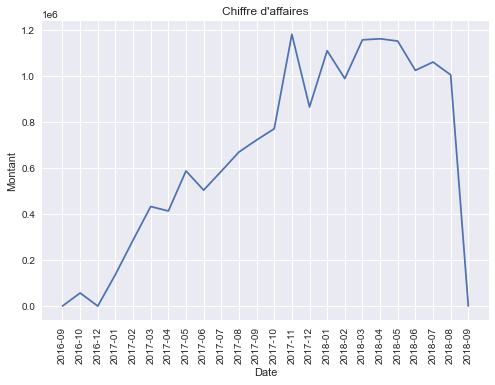

In [601]:

# get year, month, hour from order_purchase_timestamp
df_orders_extend['year'] = pd.to_datetime(df_orders_extend['order_purchase_timestamp']).dt.year
df_orders_extend['month'] = pd.to_datetime(df_orders_extend['order_purchase_timestamp']).dt.month
df_orders_extend['hour'] = pd.to_datetime(df_orders_extend['order_purchase_timestamp']).dt.hour

# group orders by year-month
df_orders_group_year_month = df_orders_extend.groupby(['year','month'])\
    .agg({"payment_value": "sum"}).reset_index()

# concat year and month values
df_orders_group_year_month["year_month"] = df_orders_group_year_month['year'].astype(str) + '-' + df_orders_group_year_month['month'].astype(str).str.pad(width=2, side='left', fillchar='0')

# plot payment_value for year-month values
g = sns.lineplot(data = df_orders_group_year_month, x = "year_month" , y = "payment_value")
g.set_xticklabels(df_temp_line["year_month"], rotation=90) 
g.set_title("Chiffre d'affaires") 
g.set_xlabel("Date")
g.set_ylabel("Montant")

plt.show()

#### paiements des commandes : outliers

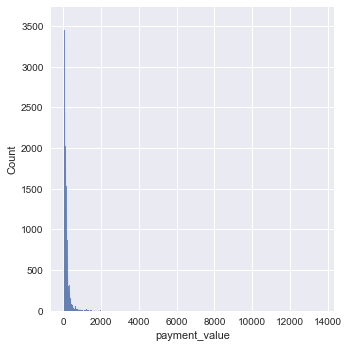

In [602]:
sns.displot(df_orders_extend['payment_value'])
plt.show()

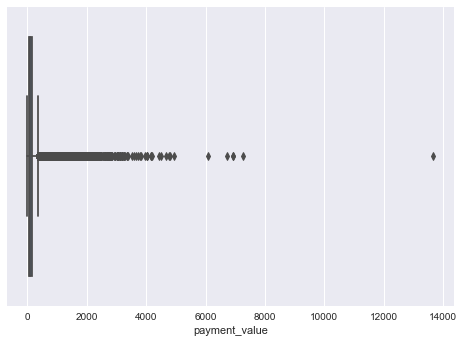

In [603]:
sns.boxplot(df_orders_extend['payment_value'])
plt.show()

Il y a de nombreux outliers.  
Bornes des valeurs atypiques :

In [604]:
# fonction retournant les bornes limites des valeurs aberrantes selon la règle de 1.5 * écart interquantile
def bornes_interquantiles(df, col):
    """calculate outliers with 1.5 * "écart interquantile"

        Parameters:
        df (dataframe): the dataframe from which outliers are calculated
        col (string): the column from which outliers are calculated

        Returns:
        array: the outliers threshold

    """    
    q1 = round(np.nanpercentile(df[col], 25))
    q3 = round(np.nanpercentile(df[col], 75))
    ecart_interquartile = q3 - q1
    borne_inferieure = q1 - 1.5 * ecart_interquartile
    borne_superieure = q3 + 1.5 * ecart_interquartile
    return [borne_inferieure,borne_superieure]


In [605]:
bornes_interquantiles(df_orders_extend,'payment_value')


[-110.5, 349.5]


Des montants supérieurs à 349.5 ne sont pas aberrants.    
Détermination de la borne par une autre méthode:    

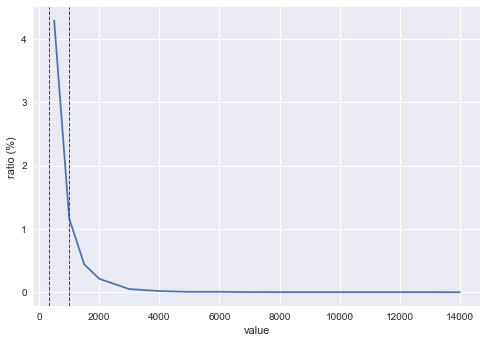

In [606]:
total_size = df_orders_extend.shape[0]
ratios = {}
value = 0

while value < df_orders_extend['payment_value'].max():
    # increment for ratios
    if value < 2000:
        increment = 500
    else:
        increment = 1000
    value += increment
    
    # calculate ratio between current values size and overall values size 
    current_size = df_orders_extend[df_orders_extend['payment_value']>value].shape[0]
    current_ratio = (current_size/total_size) * 100
    ratios[value] = current_ratio
    
    
df_payment_ratios = pd.DataFrame(list(ratios.items()), columns=['value','ratio (%)'])    

# plot the ratios for payment values
sns.lineplot(data=df_payment_ratios,x='value',y='ratio (%)')
plt.axvline(344.5,color='r',linestyle='dashed', linewidth=1)
plt.axvline(1000,color='r',linestyle='dashed', linewidth=1)
plt.show()

Environ 1% des montants sont supérieurs à 1000.  
Les commandes au delà de cette valeur seront supprimées.  

In [607]:
df_orders_extend = df_orders_extend[df_orders_extend['payment_value']<1000]

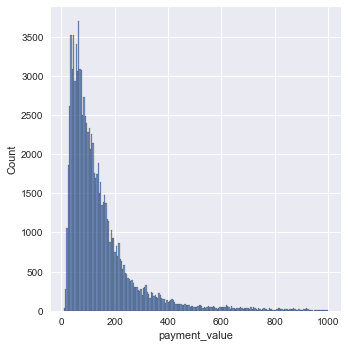

In [608]:
sns.displot(df_orders_extend['payment_value'])
plt.show()

### 4.3 - Customers <a class="anchor" id="section_4_3"></a>

#### merge des commandes et des clients

In [616]:
# merge customers and orders

df_orders_extend = df_orders_extend[df_orders_extend['order_status']=='delivered']

df_customers_extend = df_customers.merge(
    df_orders_extend, on=['customer_id'])


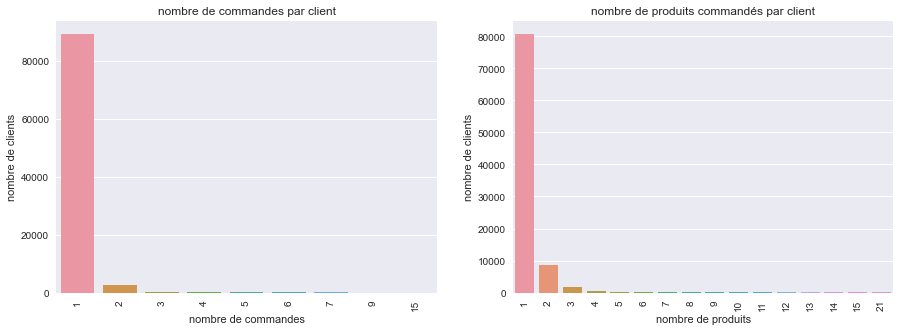

In [610]:

# group customers by unique_id
df_customers_group_unique = df_customers_extend.groupby('customer_unique_id').agg({
    'product_id': lambda x: sum(x),
    'order_id': lambda x: len(x)
}).reset_index()

# plot orders and product per customers

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

g1 = sns.countplot(ax=axes[0], data = df_customers_group_unique,x="order_id")
g1.set_xticklabels(g1.get_xticklabels(), rotation=90) 
g1.set_xlabel("nombre de commandes")
g1.set_ylabel("nombre de clients")
g1.set_title("nombre de commandes par client")

g2 = sns.countplot(ax=axes[1], data = df_customers_group_unique, x="product_id")
g2.set_xticklabels(g2.get_xticklabels(), rotation=90) 
g2.set_xlabel("nombre de produits")
g2.set_ylabel("nombre de clients")
g2.set_title("nombre de produits commandés par client")

plt.show()

## 5 - RFM - Feature engineering <a class="anchor" id="chapter5"></a>


Dans cette étude, l'objectif de la clusterisation est de déterminer des profils de clients afin de cibler les actions à effectuer.  

Afin d'effectuer une segmentation des clients, les valeurs Recency, Frequency, Monetary value (RFM) vont être crées.  
Pour la fréquence, le nombre de commandes par client étant très faible, le nombre de produits commandés par clients va être utilisé.

De plus, suite à l'analyse exploratoire, 3 autres features vont être ajoutées:  
- Le review score : permettant d'identifier les clients selon leur (mé)contentement    
- Le délai de livraison : permettant d'identifier des clients qui ont eu (ou pas) de longues attentes  
- L'heure d'achat : selon les heures d'achat, différents profils de clients peuvent exister (personnes jeunes/agées etc...)  

In [611]:

from datetime import datetime, timedelta

# convert order_purchase_timestamp to datetime
df_customers_extend['order_purchase_timestamp'] = pd.to_datetime(df_customers_extend['order_purchase_timestamp'])

# calculate the last purchase date of the dataset
last_date = df_customers_extend['order_purchase_timestamp'].max() + timedelta(days=1)

# get the purchase hour
df_customers_extend['purchase_hour'] = df_customers_extend['order_purchase_timestamp'].dt.hour

# create recency, frequency and monetary values

rfm1 = df_customers_extend.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (last_date - x.max()).days,
    'product_id': lambda x: sum(x),
    'payment_value': lambda x: sum(x)
})

rfm1 = rfm1.rename(columns={
    'order_purchase_timestamp':'recency',
    'product_id':'frequency',
    'payment_value':'monetary'
})

# add delivery delay, review score and purchase hour to rfm 

rfm2 = df_customers_extend.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (last_date - x.max()).days,
    'product_id': lambda x: sum(x),
    'payment_value': lambda x: sum(x),
    'delivery_delay_days': lambda x: np.mean(x),
    'review_score': lambda x: np.mean(x),
    'purchase_hour': lambda x: np.mean(x)
})

rfm2 = rfm2.rename(columns={
    'order_purchase_timestamp':'recency',
    'product_id':'frequency',
    'delivery_delay_days':'delivery_delay',
    'payment_value':'monetary'
})


In [612]:
rfm1

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89
...,...,...,...
fffbf87b7a1a6fa8b03f081c5f51a201,245,1,167.32
fffea47cd6d3cc0a88bd621562a9d061,262,1,84.58
ffff371b4d645b6ecea244b27531430a,568,1,112.46


In [613]:
rfm2

,recency,frequency,monetary,delivery_delay,review_score,purchase_hour
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,10.0,5.0,10.0
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,7.0,4.0,11.0
0000f46a3911fa3c0805444483337064,537,1,86.22,27.0,3.0,21.0
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,31.0,4.0,20.0
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,20.0,5.0,19.0
...,...,...,...,...,...,...
fffbf87b7a1a6fa8b03f081c5f51a201,245,1,167.32,32.0,5.0,22.0
fffea47cd6d3cc0a88bd621562a9d061,262,1,84.58,32.0,4.0,20.0
ffff371b4d645b6ecea244b27531430a,568,1,112.46,44.0,5.0,15.0


In [615]:
rfm1.reset_index().to_csv(data_path + "rfm1.csv", index=False)
rfm2.reset_index().to_csv(data_path + "rfm2.csv", index=False)


## 6 - Conclusion <a class="anchor" id="chapter6"></a>


Les données à disposition sont assez complètes et possèdent peu de valeurs manquantes, doublons, outliers.  
De ces données, des caractéristiques ciblées pour le marketing, pour les campagnes de communication ont été extraites :
- Les données RFM
- 3 autres caractéristiques (note, délai de livraison, heures d'achat)